In [1]:
import cv2
import h5py
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm as c
from keras.models import model_from_json

In [13]:
from keras.models import model_from_json
import keras

# Define your custom loss exactly as before
def euclidean_distance_loss(y_true, y_pred):
    return keras.backend.sqrt(keras.backend.sum(keras.backend.square(y_pred - y_true), axis=-1))

def load_model():
    # Load model architecture
    with open('models/Model.json', 'r') as json_file:
        loaded_model_json = json_file.read()
    
    # Tell Keras about custom loss
    loaded_model = model_from_json(
        loaded_model_json, 
        custom_objects={'euclidean_distance_loss': euclidean_distance_loss}
    )
    
    # Load weights
    loaded_model.load_weights("weights/model_A_weights.weights.h5")
    print("Model loaded successfully")
    return loaded_model


def create_img(path):
    #Function to load,normalize and return image 
    print(path)
    im = Image.open(path).convert('RGB')
    
    im = np.array(im)
    
    im = im/255.0
    
    im[:,:,0]=(im[:,:,0]-0.485)/0.229
    im[:,:,1]=(im[:,:,1]-0.456)/0.224
    im[:,:,2]=(im[:,:,2]-0.406)/0.225


    im = np.expand_dims(im,axis  = 0)
    return im

In [3]:
def predict(path):
    #Function to load image,predict heat map, generate count and return (count , image , heat map)
    model = load_model()
    image = create_img(path)
    ans = model.predict(image)
    count = np.sum(ans)
    return count,image,ans

In [16]:
ans, img, hmap = predict(r"C:\Users\User\OneDrive\Desktop\crowd_counting_project\data\part_A_final\train_data\images\IMG_150.jpg")


Model loaded successfully
C:\Users\User\OneDrive\Desktop\crowd_counting_project\data\part_A_final\train_data\images\IMG_150.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 87s 87s/step


In [17]:
print(ans,"this is ans",hmap)

285.9787 this is ans [[[[0.04219745]
   [0.04219745]
   [0.04220114]
   ...
   [0.04220115]
   [0.04219784]
   [0.04219784]]

  [[0.04219745]
   [0.04219745]
   [0.04220114]
   ...
   [0.04220115]
   [0.04219784]
   [0.04219784]]

  [[0.04219998]
   [0.04219998]
   [0.04220493]
   ...
   [0.04220491]
   [0.04220018]
   [0.04220018]]

  ...

  [[0.04219978]
   [0.04219978]
   [0.04220464]
   ...
   [0.04220469]
   [0.04220006]
   [0.04220006]]

  [[0.04219563]
   [0.04219563]
   [0.04219798]
   ...
   [0.04219802]
   [0.04219599]
   [0.04219599]]

  [[0.04219563]
   [0.04219563]
   [0.04219798]
   ...
   [0.04219802]
   [0.04219599]
   [0.04219599]]]]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1179039301310043..2.6399999999999997].


285.9787


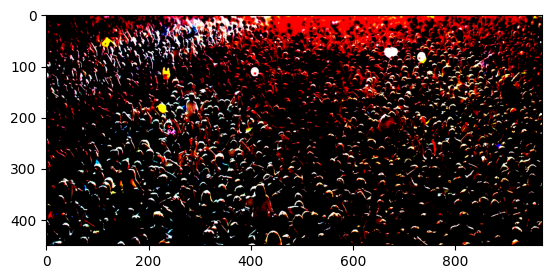

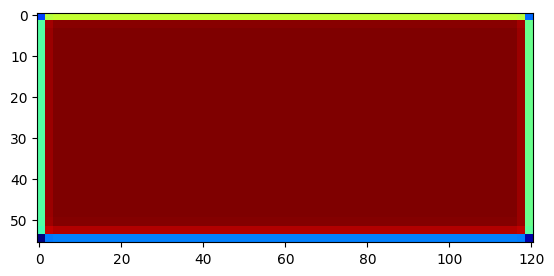

In [18]:
print(ans)
#Print count, image, heat map
plt.imshow(img.reshape(img.shape[1],img.shape[2],img.shape[3]))
plt.show()
plt.imshow(hmap.reshape(hmap.shape[1],hmap.shape[2]) , cmap = c.jet )
plt.show()

In [22]:
temp = h5py.File('data/part_A_final/test_data/ground_truth/IMG_170.h5' , 'r')
temp_1 = np.asarray(temp['density'])
#plt.imshow(temp_1,cmap = c.jet)
print("Original Count : ",int(np.sum(temp_1)) + 1)

Original Count :  664
